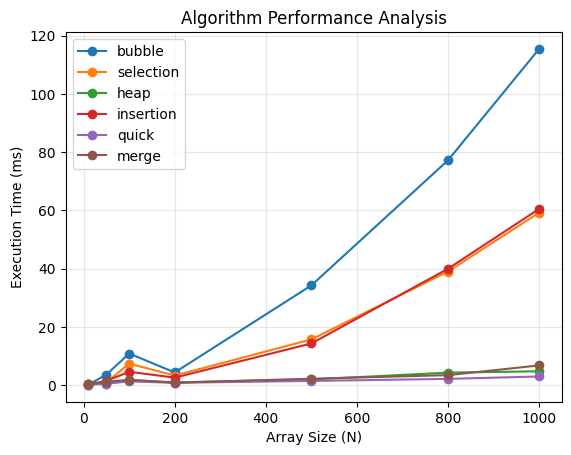

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

def collect_data():
    results = []
    sizes =[10,50,100,200,500,800,1000]
    algos=["bubble","selection","heap", "insertion","quick","merge"]

    for algo in algos:
        for size in sizes:
            params = {'algo':algo, 'size':size,'type':'Random'}
            try:
                response = requests.get(f'http://localhost:8080/api/Data', params=params)
                if response.status_code == 200:
                    results.append(response.json())
            except Exception as e:
                print(f"Error: {e}")
    return pd.DataFrame(results)

df = collect_data()
if not df.empty:
    for algo in df['algo'].unique():
        subset = df[df['algo'] == algo]
        plt.plot(subset['size'], subset['time'], label=algo, marker='o')

    plt.xlabel("Array Size (N)")
    plt.ylabel("Execution Time (ms)")
    plt.title("Algorithm Performance Analysis")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("DataFrame is empty. Check your Spring Boot backend connection.")